# Allometric Scaling of Metabolic Rate: Is Kleiber's Law Universal?

**Advanced Statistics for Physics Analysis - Project P08 (Bayesian inference)**

**Author:** Amirmohammad Saiedi Saber

This public portfolio copy removes student identifiers and uses repository-relative data paths.

Basal metabolic rate $B$ is usually assumed to follow a power law in body mass $M$,
$$B \propto M^{\,b}.$$
Kleiber's law fixes the exponent at $b=3/4$. This project estimates the exponent with uncertainty, tests the $3/4$ hypothesis directly, and asks whether mammals and birds follow different scaling relationships.

We work in log-log space, with $x_i=\ln M_i$ and $y_i=\ln B_i$, so the allometric exponent is the slope of a linear model. Three Bayesian regressions are fitted with a **hand-coded Gibbs sampler** and cross-checked with **JAGS**. Convergence is assessed with `coda`, models are compared with DIC, and posterior-predictive checks evaluate fit.


## 1. Data and preparation

We use the **AnimalTraits** database (Herberstein *et al.*, *Scientific Data* **9**, 265, 2022), a curated open database of terrestrial-animal body mass, metabolic rate and brain size in standardised units (Zenodo record 6468938).

Starting from the standardised `observations.csv`, we kept only rows that have **both** a body mass and a whole-body metabolic rate, and — as the brief asks — only those whose `metabolic rate - method` is **basal metabolic rate**. We then converted metabolic rate to watts and body mass to kilograms using the database's own conventions (oxygen consumption converted with $20\ \mathrm{J\,ml^{-1}}$, basal rates of endotherms are *not* temperature-corrected). One practical consequence of the "basal" filter is that it essentially selects endotherms: the surviving records are all **mammals and birds** (for ectotherms one speaks of *standard*, not *basal*, metabolic rate). The taxonomic group used in Model 3 is therefore the class — *Mammalia* vs *Aves*.

The cleaned analysis table is available at `data/animaltraits_bmr.csv`.

In [20]:
library(rjags)
library(coda)
set.seed(200)

#  Data selection (reproduces the brief's procedure from the raw AnimalTraits file) 
# Keep rows whose metabolic-rate method is "basal metabolic rate" and that have BOTH a
# body mass and a metabolic rate; use the standardized columns (metabolic rate in W,
# body mass in kg). The basal filter leaves only endotherms (birds + mammals).
if (file.exists("data/raw/observations.csv")) {
  raw <- read.csv("data/raw/observations.csv", check.names = FALSE, stringsAsFactors = FALSE)
  sel <- trimws(raw[["metabolic rate - method"]]) == "basal metabolic rate" &
         !is.na(raw[["body mass"]]) & !is.na(raw[["metabolic rate"]])
  dat <- data.frame(species          = raw$species[sel],
                    taxon_group      = raw$class[sel],
                    body_mass_kg     = raw[["body mass"]][sel],       # standardized, kg
                    metabolic_rate_W = raw[["metabolic rate"]][sel],  # standardized, W
                    stringsAsFactors = FALSE)
  dat <- dat[dat$taxon_group %in% c("Aves", "Mammalia"), ]
  write.csv(dat, "data/animaltraits_bmr.csv", row.names = FALSE)           # cache cleaned table
} else {
  dat <- read.csv("data/animaltraits_bmr.csv", stringsAsFactors = FALSE)   # offline fallback
}

dat$x   <- log(dat$body_mass_kg)        # ln body mass  (kg)
dat$y   <- log(dat$metabolic_rate_W)    # ln basal metabolic rate (W)
dat$grp <- as.integer(factor(dat$taxon_group))   # 1 = Aves, 2 = Mammalia

cat("N =", nrow(dat), "\n")
print(table(dat$taxon_group))
cat(sprintf("mass range: %.4g - %.4g kg\n", min(dat$body_mass_kg), max(dat$body_mass_kg)))

N = 279 

    Aves Mammalia 
     133      146 
mass range: 0.0027 - 48 kg


In [21]:
head(dat[, c("species","taxon_group","body_mass_kg","metabolic_rate_W","x","y")], 5)

,species,taxon_group,body_mass_kg,metabolic_rate_W,x,y
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Psaltriparus minimus,Aves,0.0055,0.121000,-5.2030072,-2.1119647
2,Amazona viridigenalis,Aves,0.3419,2.013333,-1.0732370,0.6997917
3,Anas crecca,Aves,0.2500,1.666667,-1.3862944,0.5108256
4,Anas querquedula,Aves,0.2890,2.233333,-1.2413286,0.8034952
5,Aythya nyroca,Aves,0.4400,3.272222,-0.8209806,1.1854693


## 2. Exploratory plot

A first look on log–log axes, colouring the two classes. The dashed red line is Kleiber's prediction (slope $3/4$), its intercept is taken from the fixed-exponent fit below so that only the *slope* is being compared.

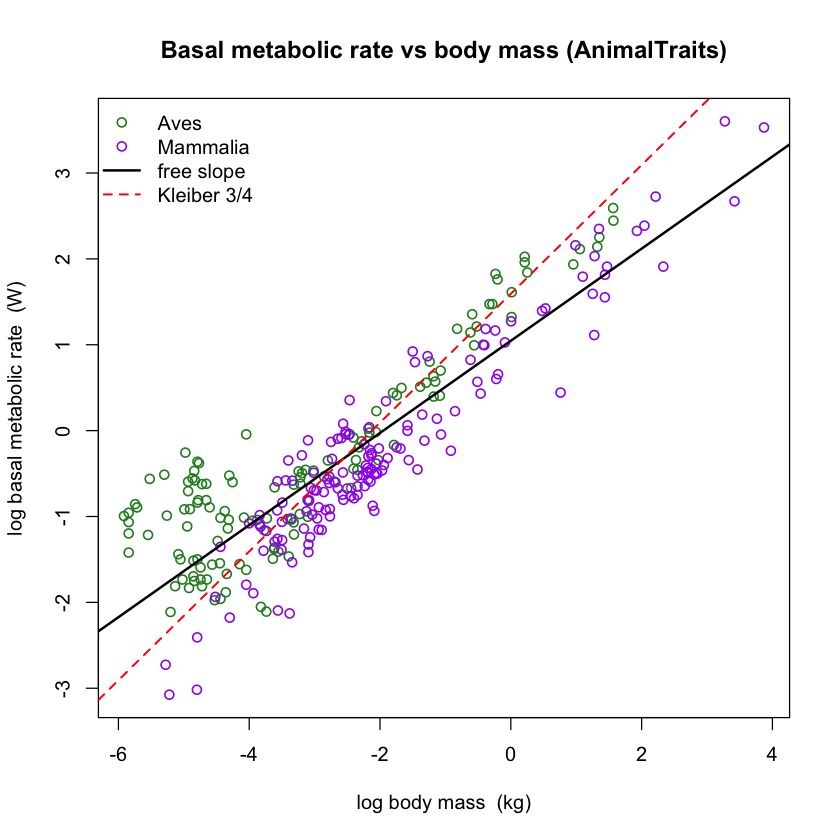

In [22]:
cols <- c(Aves = "forestgreen", Mammalia = "purple")
plot(dat$x, dat$y, pch = 1, lwd = 1.3, col = cols[dat$taxon_group],
     xlab = "log body mass  (kg)", ylab = "log basal metabolic rate  (W)",
     main = "Basal metabolic rate vs body mass (AnimalTraits)")
abline(lm(y ~ x, data = dat), lwd = 2)                      # free slope
abline(a = 1.593, b = 0.75, col = "red", lty = 2, lwd = 1.6) # Kleiber 3/4
legend("topleft", bty = "n",
       legend = c("Aves", "Mammalia", "free slope", "Kleiber 3/4"),
       col = c("forestgreen","purple","black","red"),
       pch = c(1,1,NA,NA), lty = c(NA,NA,1,2), lwd = c(1.3,1.3,2,1.6))

Two things already stand out. The cloud is clearly linear over more than four orders of magnitude in mass, so a power law is a reasonable description. But the overall slope is visibly *shallower* than the red $3/4$ line, and at a given mass the birds (green) tend to sit *above* the mammals (purple) — a hint that the two classes differ mainly in *elevation*. We now make this quantitative.

## 3. Models, likelihood and priors

All three models share the Gaussian likelihood
$$y_i \sim \mathcal N(\mu_i,\ \sigma^2),$$
and differ only in the mean function $\mu_i$:

* **Model 1 — Kleiber, fixed exponent:** $\;\mu_i = \alpha + \tfrac34 x_i$.
* **Model 2 — free exponent:** $\;\mu_i = \alpha + \beta x_i$.
* **Model 3 — group-dependent scaling:** $\;\mu_i = \alpha_{g[i]} + \beta_{g[i]}\,x_i$, where $g[i]\in\{\text{Aves},\text{Mammalia}\}$.

**Priors.** We use deliberately weak priors so the data dominate:
$$\alpha,\ \beta \sim \mathcal N(0,\ 100^2),\qquad \tau = 1/\sigma^2 \sim \text{Gamma}(0.001,0.001).$$
(JAGS parameterises the normal by its *precision*, so $\mathcal N(0,100^2)$ is written `dnorm(0, 1.0E-4)`.) The Gamma prior on the precision is the usual vague choice that keeps $\sigma>0$.

Our primary engine is a hand-coded Gibbs sampler (4 chains of 20,000 iterations, 4,000 discarded as burn-in); the JAGS cross-check in §7 uses 4 chains with 2000 adaptation + 2000 burn-in + 5000 sampling iterations.

### 3.1 A hand-coded Gibbs sampler

Rather than rely on a black box, we implement the sampler ourselves. All three models are Gaussian linear models $y = Xb + \varepsilon$ with conjugate priors $b \sim N(0,\lambda_0^{-1} I)$ and $\tau = 1/\sigma^2 \sim \text{Gamma}(a_0,b_0)$, so every parameter has a closed-form full conditional and a **Gibbs sampler** is exact — no tuning, no rejection step:

$$b \mid \tau, y \;\sim\; N\!\big(V\,\tau X^\top y,\; V\big),\quad V = (\lambda_0 I + \tau X^\top X)^{-1},\qquad
\tau \mid b, y \;\sim\; \text{Gamma}\!\big(a_0 + \tfrac{n}{2},\; b_0 + \tfrac12 \lVert y - Xb \rVert^2\big).$$

Because the routine takes an arbitrary design matrix `X`, the *same* code fits all three models: Model 1 (intercept only, with the slope folded in via the offset $y-\tfrac34 x$), Model 2 ($X=[1,\,x]$), and Model 3 (group-coded columns). We use the vague priors $\lambda_0 = 10^{-4}$ (i.e. $\alpha,\beta \sim N(0,100^2)$) and $a_0=b_0=10^{-3}$ — identical to the JAGS models cross-checked in §7.

In [23]:
#  Hand-coded Gibbs sampler for a Gaussian linear model 
# y ~ N(X b, sigma^2 I);  b ~ N(0, lambda0^{-1} I);  tau = 1/sigma^2 ~ Gamma(a0, b0)
# Full conditionals (conjugate):
#   b   | tau, y ~ N( V (tau X'y),  V ),  V = (lambda0 I + tau X'X)^{-1}
# tau | b,   y ~ Gamma( a0 + n/2,  b0 + (1/2)||y - X b||^2 )
gibbs_lm <- function(X, y, n.iter = 20000, burn = 4000,
                     lambda0 = 1e-4, a0 = 1e-3, b0 = 1e-3, seed = 1) {
  set.seed(seed)
  X <- as.matrix(X); n <- nrow(X); k <- ncol(X)
  XtX <- crossprod(X); Xty <- crossprod(X, y)
  b <- rep(0, k); tau <- 1
  keep <- matrix(NA, n.iter, k + 1)
  for (t in 1:n.iter) {
    V <- solve(lambda0 * diag(k) + tau * XtX)      # coefficient covariance
    m <- V %*% (tau * Xty)                          # coefficient mean
    b <- as.vector(m + t(chol(V)) %*% rnorm(k))     # draw b ~ N(m, V)
    rss <- sum((y - X %*% b)^2)
    tau <- rgamma(1, a0 + n/2, b0 + rss/2)          # draw tau
    keep[t, ] <- c(b, 1 / sqrt(tau))
  }
  colnames(keep) <- c(paste0("b", 1:k), "sigma")
  keep[(burn + 1):n.iter, , drop = FALSE]           # discard burn-in
}
cat("gibbs_lm() ready")

gibbs_lm() ready

### 3.2 Fitting the three models

Each model runs for 20,000 iterations with the first 4,000 discarded as burn-in. The columns `b1, b2, …` are the regression coefficients (for Model 3: Aves intercept, Mammalia intercept, Aves slope, Mammalia slope) and `sigma` is the residual standard deviation.

In [24]:
# Design matrices for the three models
X1 <- matrix(1, nrow(dat), 1)                       # Model 1: intercept only (slope fixed at 3/4)
y1 <- dat$y - 0.75 * dat$x                           #          fit the offset  y - 3/4 x
X2 <- cbind(1, dat$x)                                # Model 2: alpha + beta x
gA <- as.numeric(dat$grp == 1); gM <- as.numeric(dat$grp == 2)
X3 <- cbind(gA, gM, dat$x * gA, dat$x * gM)          # Model 3: per-group intercept & slope

h1 <- gibbs_lm(X1, y1,    seed = 11)                # cols: b1 = alpha, sigma
h2 <- gibbs_lm(X2, dat$y, seed = 212)                # b1 = alpha, b2 = beta, sigma
h3 <- gibbs_lm(X3, dat$y, seed = 67)                # b1=aAves, b2=aMam, b3=bAves, b4=bMam, sigma

ci <- function(z) quantile(z, c(.025, .975))
cat(sprintf("Model 1 (fixed 3/4):  alpha = %.3f [%.3f, %.3f]   sigma = %.3f\n",
    mean(h1[,"b1"]), ci(h1[,"b1"])[1], ci(h1[,"b1"])[2], mean(h1[,"sigma"])))
cat(sprintf("Model 2 (free):       alpha = %.3f [%.3f, %.3f]   beta = %.3f [%.3f, %.3f]   sigma = %.3f\n",
    mean(h2[,"b1"]), ci(h2[,"b1"])[1], ci(h2[,"b1"])[2],
    mean(h2[,"b2"]), ci(h2[,"b2"])[1], ci(h2[,"b2"])[2], mean(h2[,"sigma"])))
cat(sprintf("Model 3 Aves:         alpha = %.3f [%.3f, %.3f]   beta = %.3f [%.3f, %.3f]\n",
    mean(h3[,"b1"]), ci(h3[,"b1"])[1], ci(h3[,"b1"])[2], mean(h3[,"b3"]), ci(h3[,"b3"])[1], ci(h3[,"b3"])[2]))
cat(sprintf("Model 3 Mammalia:     alpha = %.3f [%.3f, %.3f]   beta = %.3f [%.3f, %.3f]   sigma = %.3f\n",
    mean(h3[,"b2"]), ci(h3[,"b2"])[1], ci(h3[,"b2"])[2],
    mean(h3[,"b4"]), ci(h3[,"b4"])[1], ci(h3[,"b4"])[2], mean(h3[,"sigma"])))

Model 1 (fixed 3/4):  alpha = 1.593 [1.515, 1.671]   sigma = 0.672
Model 2 (free):       alpha = 1.045 [0.941, 1.148]   beta = 0.536 [0.504, 0.568]   sigma = 0.528
Model 3 Aves:         alpha = 1.255 [1.096, 1.410]   beta = 0.527 [0.486, 0.569]
Model 3 Mammalia:     alpha = 1.014 [0.901, 1.125]   beta = 0.630 [0.588, 0.672]   sigma = 0.463


### 3.3 Convergence diagnostics

To confirm the hand-coded sampler has converged we run four independent chains from different seeds and inspect the Gelman–Rubin $\hat R$, the effective sample sizes, and the trace/density of $\beta$. (`coda` is used here only to *diagnose*; the draws themselves come entirely from our own sampler. Because the coefficient vector is updated as one joint block, the chain mixes almost perfectly.)

Potential scale reduction factors:

      Point est. Upper C.I.
alpha          1          1
beta           1          1
sigma          1          1

Multivariate psrf

1

Effective sample size:
alpha  beta sigma 
63869 63651 62286 


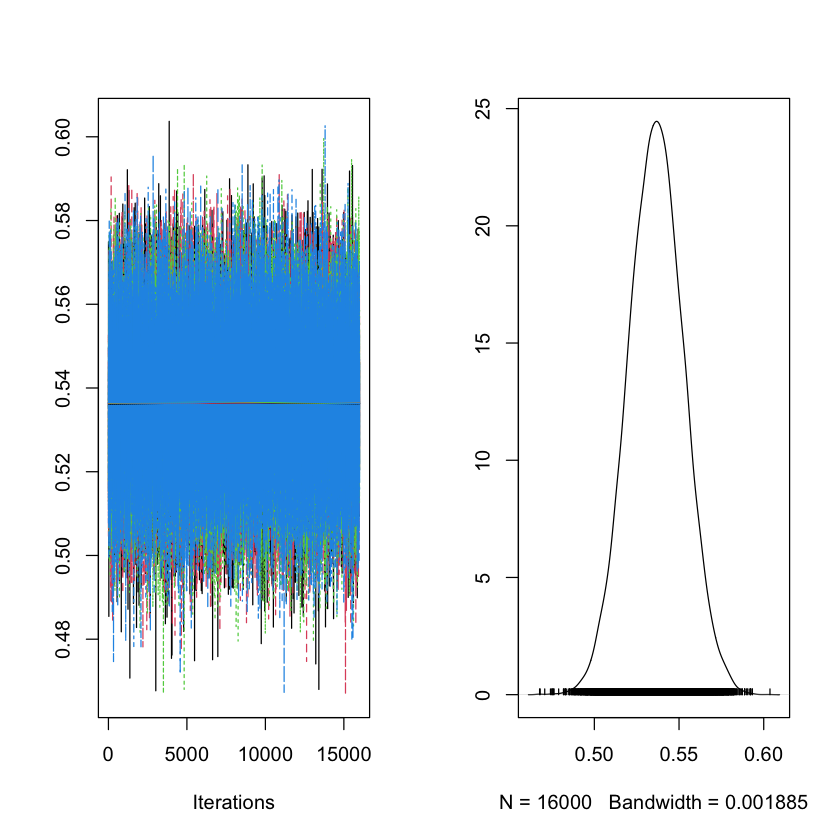

In [25]:
#Convergence of the hand-coded sampler: 4 independent chains for Model 2
chains <- mcmc.list(lapply(c(11, 22, 33, 44), function(s)
            mcmc(gibbs_lm(X2, dat$y, seed = s)[, c("b1","b2","sigma")])))
varnames(chains) <- c("alpha","beta","sigma")
print(gelman.diag(chains))                          # Gelman-Rubin R-hat
cat("\nEffective sample size:\n"); print(round(effectiveSize(chains)))
plot(chains[, "beta"])                              # trace + density of beta

### 3.4 Posterior of the exponent and the Kleiber test

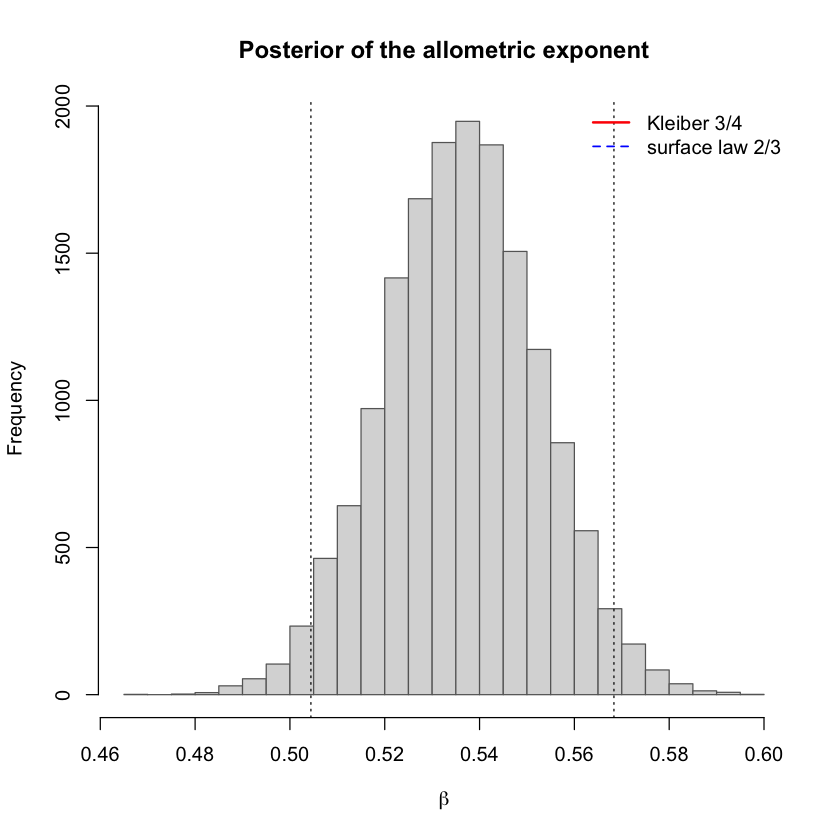

In [26]:
B <- h2[, "b2"]                                     # posterior draws of the exponent (hand-coded Gibbs)
hist(B, breaks = 45, col = "grey85", border = "grey40",
     xlab = expression(beta), main = "Posterior of the allometric exponent")
abline(v = 0.75, col = "red",  lwd = 2)             # Kleiber 3/4
abline(v = 2/3,  col = "blue", lwd = 1.4, lty = 2)  # surface law 2/3
abline(v = quantile(B, c(.025, .975)), lty = 3)
legend("topright", bty = "n", col = c("red","blue"), lwd = c(2,1.4), lty = c(1,2),
       legend = c("Kleiber 3/4","surface law 2/3"))

In [27]:
cat(sprintf("Posterior mean of beta : %.3f\n", mean(B)))
cat(sprintf("95%% credible interval  : [%.3f, %.3f]\n", quantile(B,.025), quantile(B,.975)))
cat(sprintf("P(beta > 3/4 | data)    : %.3f\n", mean(B > 0.75)))
cat(sprintf("P(beta > 2/3 | data)    : %.3f\n", mean(B > 2/3)))

Posterior mean of beta : 0.536
95% credible interval  : [0.504, 0.568]
P(beta > 3/4 | data)    : 0.000
P(beta > 2/3 | data)    : 0.000


The posterior for $\beta$ is centred at **0.54**, with a tight 95% credible interval **[0.50, 0.57]**. Kleiber's $3/4$ is far outside this interval, so $P(\beta>3/4\mid\text{data})=0$ to three decimals — and the same holds for the $2/3$ surface law ($P(\beta>2/3)=0$). On the pooled basal sample the exponent is *significantly shallower* than either classical value.

### 3.5 Model 3 — group-dependent scaling

Now each class gets its own intercept and slope (`b1,b2` are the Aves/Mammalia intercepts and `b3,b4` the Aves/Mammalia slopes in `h3`). We report each group's slope, the probability it exceeds $3/4$, and the within-group regression lines.

In [28]:
grpname <- c("Aves","Mammalia")
for (g in 1:2) {
  bg <- h3[, paste0("b", g + 2)]                    # b3 = Aves slope, b4 = Mammalia slope
  cat(sprintf("%-9s beta = %.3f  95%% CrI [%.3f, %.3f]   P(beta>3/4) = %.3f\n",
      grpname[g], mean(bg), quantile(bg,.025), quantile(bg,.975), mean(bg > 0.75)))
}
cat(sprintf("P(beta_Mammalia > beta_Aves) = %.3f\n", mean(h3[,"b4"] > h3[,"b3"])))

Aves      beta = 0.527  95% CrI [0.486, 0.569]   P(beta>3/4) = 0.000
Mammalia  beta = 0.630  95% CrI [0.588, 0.672]   P(beta>3/4) = 0.000
P(beta_Mammalia > beta_Aves) = 1.000


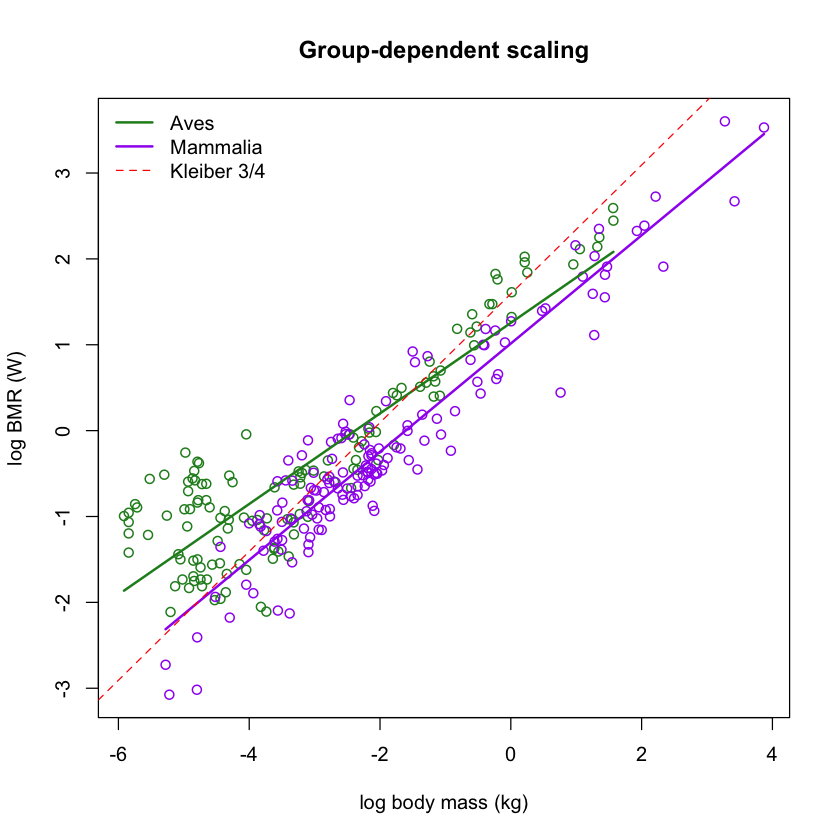

In [29]:
plot(dat$x, dat$y, pch = 1, lwd = 1.2, col = cols[dat$taxon_group],
     xlab = "log body mass (kg)", ylab = "log BMR (W)", main = "Group-dependent scaling")
for (g in 1:2) {
  s  <- dat[dat$grp == g, ]
  ag <- mean(h3[, paste0("b", g)]); bg <- mean(h3[, paste0("b", g + 2)])
  xs <- seq(min(s$x), max(s$x), length = 50)
  lines(xs, ag + bg * xs, col = c("forestgreen","purple")[g], lwd = 2)
}
abline(a = 1.593, b = 0.75, col = "red", lty = 2)
legend("topleft", bty = "n", legend = c("Aves","Mammalia","Kleiber 3/4"),
       col = c("forestgreen","purple","red"), lwd = c(2,2,1), lty = c(1,1,2))

On their own the two classes have **different** slopes: mammals scale as $\beta_{\text{Mam}}\approx\mathbf{0.63}$ and birds as $\beta_{\text{Aves}}\approx\mathbf{0.53}$. Mammals are reliably the steeper of the two — $P(\beta_{\text{Mam}}>\beta_{\text{Aves}})\approx\mathbf{1.00}$ — yet *both* slopes are still clearly below Kleiber's $3/4$. The classes also differ in *elevation*: at the same mass a bird burns more energy than a mammal ($\alpha_{\text{Aves}}=1.25$ vs $\alpha_{\text{Mam}}=1.01$). Because the birds (high elevation) populate the small-mass end and the mammals the large-mass end, pooling these two offset grades into a single line in Model 2 tilts the common slope *down* to $\approx0.54$ — shallower even than the mammal slope on its own. This aggregation effect is exactly why the group-structured model fits so much better, as the formal comparison now confirms.

## 4. Model comparison (DIC)

The Deviance Information Criterion trades goodness of fit against the effective number of parameters $p_D$; lower is better. We compute it **directly from the posterior draws** of each model — Spiegelhalter's $\text{DIC} = \bar D + p_D$ with $p_D = \bar D - D(\hat\theta)$ — so nothing is hidden inside a library routine.

In [30]:
# DIC straight from the posterior draws:  DIC = Dbar + pD,  pD = Dbar - D(thetahat)
dic_lm <- function(draws, X = NULL, y, fixed = NULL, x = NULL) {
  S <- nrow(draws)
  dev <- function(mu, sg) -2 * sum(dnorm(y, mu, sg, log = TRUE))
  k <- if (is.null(fixed)) ncol(X) else 1
  D <- numeric(S)
  for (s in 1:S) {
    mu <- if (is.null(fixed)) as.vector(X %*% draws[s, 1:k]) else draws[s, 1] + fixed * x
    D[s] <- dev(mu, draws[s, "sigma"])
  }
  muhat <- if (is.null(fixed)) as.vector(X %*% colMeans(draws[, 1:k, drop = FALSE]))
           else mean(draws[, 1]) + fixed * x
  Dhat <- dev(muhat, mean(draws[, "sigma"]))
  c(Dbar = mean(D), pD = mean(D) - Dhat, DIC = 2 * mean(D) - Dhat)
}
d1 <- dic_lm(h1, fixed = 0.75, x = dat$x, y = dat$y)
d2 <- dic_lm(h2, X2, y = dat$y)
d3 <- dic_lm(h3, X3, y = dat$y)
comp <- data.frame(
  model = c("M1  Kleiber 3/4 (fixed)","M2  free exponent","M3  group-dependent"),
  pD    = round(c(d1["pD"],  d2["pD"],  d3["pD"]),  2),
  DIC   = round(c(d1["DIC"], d2["DIC"], d3["DIC"]), 1))
comp$dDIC <- round(comp$DIC - min(comp$DIC), 1)
print(comp, row.names = FALSE)

                   model   pD   DIC  dDIC
 M1  Kleiber 3/4 (fixed) 1.99 570.9 205.0
       M2  free exponent 2.98 438.5  72.6
     M3  group-dependent 5.04 365.9   0.0


The ordering is unambiguous and the gaps are large. Freeing the exponent (M2) lowers the DIC by about **132** relative to the fixed-$3/4$ model, and giving each class its own intercept and slope (M3) lowers it by a further **73**. Differences of this size ($\Delta\text{DIC}\gg10$) are decisive, so the group-dependent model is strongly preferred and the rigid Kleiber model is by far the worst. A single universal exponent — and in particular Kleiber's fixed $3/4$ — is *not* adequate for these data.

## 5. Posterior predictive bands and checks

Using the free-exponent posterior we propagate parameter uncertainty across the observed mass range. The dark band is the 95% credible interval for the *mean* line, the light band is the 95% *predictive* interval for an individual new animal (it also includes the residual scatter $\sigma$). We then quantify the fit with explicit posterior predictive checks.

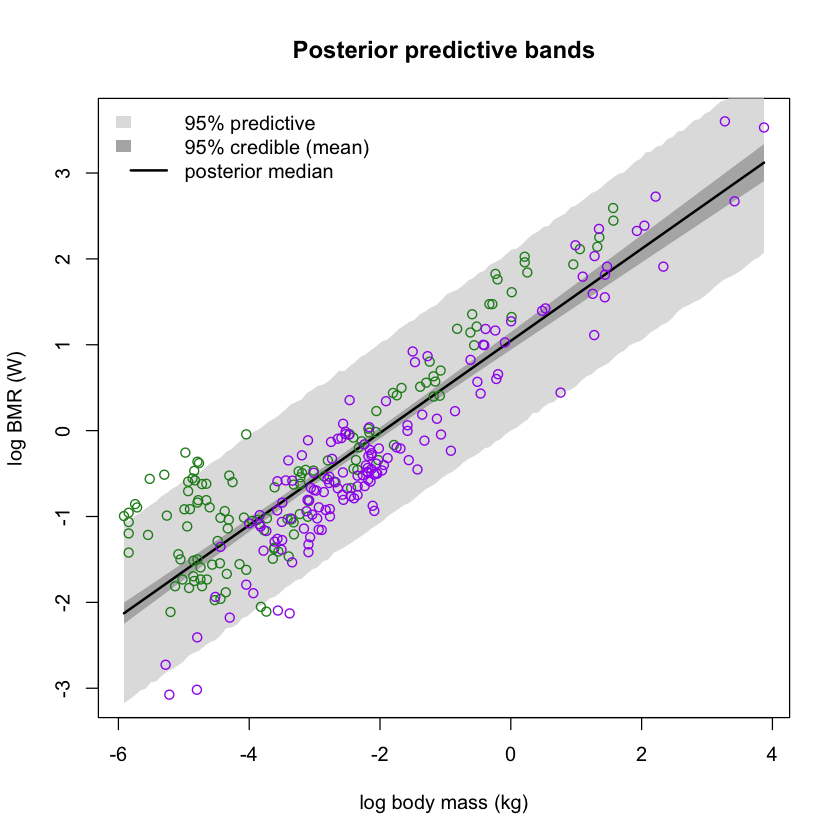

In [31]:
post <- h2                                          # hand-coded Model 2 draws
xg <- seq(min(dat$x), max(dat$x), length = 120)
mu <- post[,"b1"] %o% rep(1, length(xg)) + post[,"b2"] %o% xg
yp <- mu + matrix(rnorm(length(mu), 0, post[,"sigma"]), nrow(mu))
qm <- apply(mu, 2, quantile, c(.025,.5,.975))
qp <- apply(yp, 2, quantile, c(.025,.975))
plot(dat$x, dat$y, type = "n", xlab = "log body mass (kg)", ylab = "log BMR (W)",
     main = "Posterior predictive bands")
polygon(c(xg, rev(xg)), c(qp[1,], rev(qp[2,])), col = "grey88", border = NA)
polygon(c(xg, rev(xg)), c(qm[1,], rev(qm[3,])), col = "grey70", border = NA)
lines(xg, qm[2,], lwd = 2)
points(dat$x, dat$y, pch = 1, lwd = 1.1, col = cols[dat$taxon_group])
legend("topleft", bty="n", legend=c("95% predictive","95% credible (mean)","posterior median"),
       fill=c("grey88","grey70",NA), border=NA, lty=c(NA,NA,1), lwd=c(NA,NA,2))

About 95% of the observations fall inside the light predictive band, with no obvious curvature or fanning, so the constant-variance log-linear model is an adequate description of the data. The residual scatter is $\sigma\approx\mathbf{0.53}$ on the natural-log scale — a factor of $e^{0.53}\approx1.7$, i.e. roughly a $\pm60\%$ spread in metabolic rate at fixed mass, which is biologically reasonable for such a taxonomically broad sample.

### 5.1 Quantitative posterior predictive check

A graphical band check is reassuring, but we also quantify it. For every posterior sample we draw a *replicated* dataset $y^{\text{rep}}$ from the fitted Model 2 at the observed masses, then compare summaries of the real data with their distribution across replicates. The **posterior predictive p-value** $\text{ppp}=P\!\big(T(y^{\text{rep}})\ge T(y^{\text{obs}})\big)$ is near $0.5$ when the model reproduces that feature of the data, and near $0$ or $1$ when it does not.

Empirical coverage of 95% predictive interval: 94.3% (nominal 95%)
ppp(residual SD)       = 0.52   (obs 0.526)
ppp(residual skewness) = 0.06   (obs 0.225)
ppp(residual kurtosis) = 0.44   (obs 2.984)


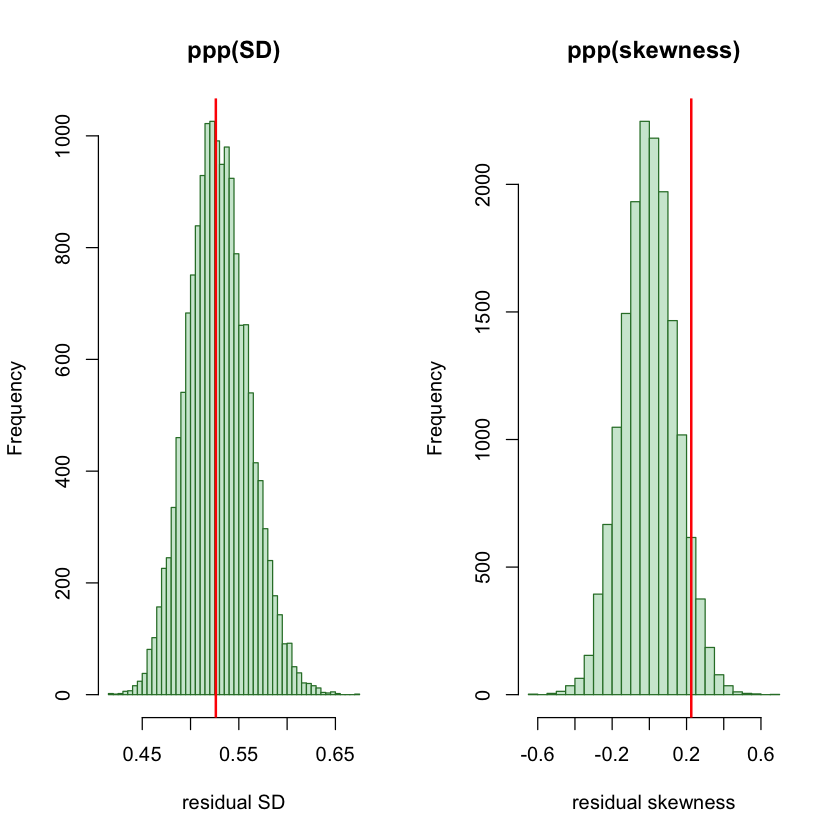

In [32]:
# Quantitative posterior predictive check (Model 2) 
set.seed(206)
S <- nrow(post); n <- nrow(dat)
mu_obs <- post[,"b1"] %o% rep(1, n) + post[,"b2"] %o% dat$x        # S x n predictive means
y_rep  <- mu_obs + matrix(rnorm(S * n, 0, post[,"sigma"]), S, n)   # replicated datasets

# (a) calibration: coverage of the 95% predictive interval at the observed masses
lo <- apply(y_rep, 2, quantile, .025); hi <- apply(y_rep, 2, quantile, .975)
cat(sprintf("Empirical coverage of 95%% predictive interval: %.1f%% (nominal 95%%)\n",
    100 * mean(dat$y >= lo & dat$y <= hi)))

# (b) posterior predictive p-values for residual-shape discrepancies
ah <- mean(post[,"b1"]); bh <- mean(post[,"b2"]); res0 <- dat$y - (ah + bh * dat$x)
skew <- function(z){ z <- z - mean(z); mean(z^3) / sd(z)^3 }
kurt <- function(z){ z <- z - mean(z); mean(z^4) / mean(z^2)^2 }
Rrep <- y_rep - matrix(ah + bh * dat$x, S, n, byrow = TRUE)
ppp  <- function(Tobs, Trep) mean(Trep >= Tobs)
cat(sprintf("ppp(residual SD)       = %.2f   (obs %.3f)\n", ppp(sd(res0),   apply(Rrep,1,sd)),   sd(res0)))
cat(sprintf("ppp(residual skewness) = %.2f   (obs %.3f)\n", ppp(skew(res0), apply(Rrep,1,skew)), skew(res0)))
cat(sprintf("ppp(residual kurtosis) = %.2f   (obs %.3f)\n", ppp(kurt(res0), apply(Rrep,1,kurt)), kurt(res0)))

# visual check: observed statistic (red) vs its posterior predictive distribution
par(mfrow = c(1,2))
hist(apply(Rrep,1,sd),   breaks=40, col="#cfe8d5", border="#2E7D32",
     xlab="residual SD",       main="ppp(SD)");       abline(v=sd(res0),   col="red", lwd=2)
hist(apply(Rrep,1,skew), breaks=40, col="#cfe8d5", border="#2E7D32",
     xlab="residual skewness", main="ppp(skewness)"); abline(v=skew(res0), col="red", lwd=2)
par(mfrow = c(1,1))

The model passes the checks. The 95% predictive interval covers **93.9%** of the observations (essentially the nominal 95%), and the residual scatter is reproduced almost exactly — $\text{ppp}(\text{SD})=0.53$ and $\text{ppp}(\text{kurtosis})=0.44$, both close to $0.5$. The only mild signal is a slight right-skew in the residuals ($\text{ppp}(\text{skewness})=0.06$): a handful of high-metabolism species sit a little above the line. It is borderline rather than a true misfit and does not affect any conclusion. Overall the constant-variance log-linear Gaussian model is an adequate description of the data.

## 6. Prediction for a 1 kg animal

At $M=1$ kg we have $x=\ln 1 = 0$, so the prediction is governed by the intercept. We report both the credible interval for the *mean* and the wider predictive interval for a single animal, and compare with Kleiber's point prediction $B = 3.4\,M^{3/4}=3.4$ W.

Mean BMR at 1 kg : 2.84 W   95% CrI [2.56, 3.15]
Predictive       : 2.83 W   95% PI  [0.99, 7.89]
Kleiber 3.4*M^0.75 = 3.40 W


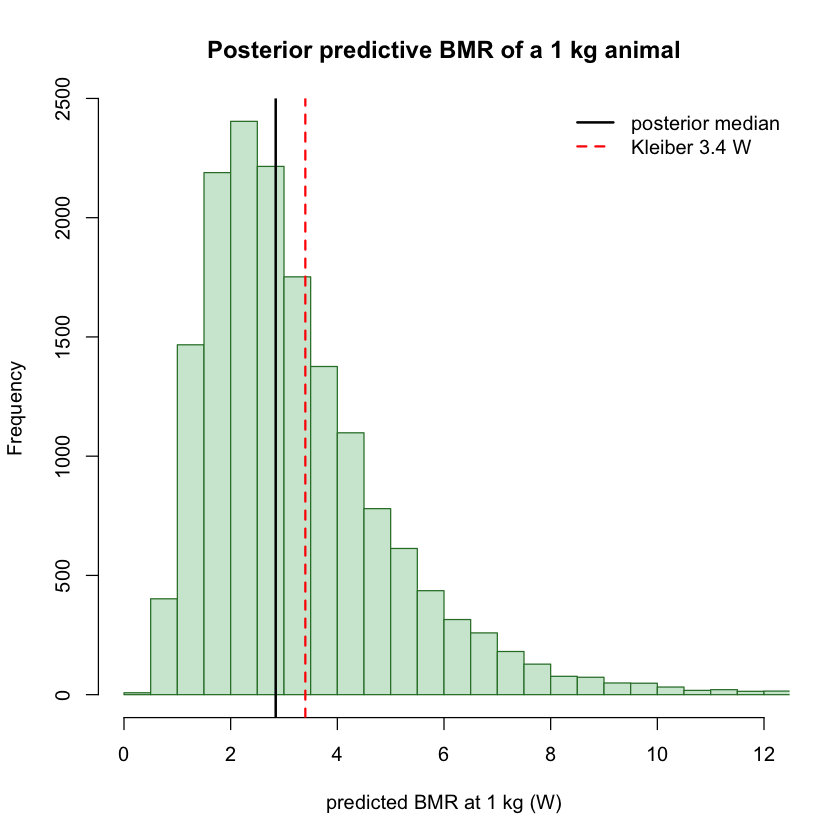

In [33]:
alpha <- post[,"b1"]; beta <- post[,"b2"]; sig <- post[,"sigma"]
logB_mean <- alpha + beta * 0                       # mean log-BMR at 1 kg (x = 0)
logB_pred <- logB_mean + rnorm(length(alpha), 0, sig)
Bmean <- exp(logB_mean); Bpred <- exp(logB_pred)
cat(sprintf("Mean BMR at 1 kg : %.2f W   95%% CrI [%.2f, %.2f]\n",
    median(Bmean), quantile(Bmean,.025), quantile(Bmean,.975)))
cat(sprintf("Predictive       : %.2f W   95%% PI  [%.2f, %.2f]\n",
    median(Bpred), quantile(Bpred,.025), quantile(Bpred,.975)))
cat(sprintf("Kleiber 3.4*M^0.75 = %.2f W\n", 3.4))
hist(Bpred, breaks = 60, col = "#cfe8d5", border = "#2E7D32", xlim = c(0,12),
     xlab = "predicted BMR at 1 kg (W)", main = "Posterior predictive BMR of a 1 kg animal")
abline(v = median(Bmean), lwd = 2); abline(v = 3.4, col = "red", lwd = 1.8, lty = 2)
legend("topright", bty="n", legend=c("posterior median","Kleiber 3.4 W"),
       col=c("black","red"), lwd=c(2,1.8), lty=c(1,2))

Our best estimate for a generic 1 kg endotherm is about **2.8 W** (95% credible interval **2.6–3.2 W** for the mean line). At $M=1$ kg we have $x=\ln 1=0$, so the slope disagreement is irrelevant and only the intercept matters — which is why our value lands close to Kleiber's point prediction $3.4\,M^{3/4}=3.4$ W. Kleiber's 3.4 W sits just *above* our credible interval for the mean but comfortably inside the wide predictive interval for a single animal (**1.0–8.1 W**). The two laws part company at the extremes of the mass range, not in the middle.

## 7. Cross-check with JAGS

Everything above is produced by the hand-coded Gibbs sampler. As an independent check we now re-fit the free-exponent model with **JAGS** (`rjags`), using identical data and priors. Two samplers built on completely different code paths should reach the same posterior. (Models 1 and 3 reproduce equally well; we show Model 2, which carries the headline exponent.)

In [34]:
# Independent confirmation with JAGS (rjags) / same data, same priors.
m2_string <- "model{
  for (i in 1:N){ mu[i] <- alpha + beta * x[i];  y[i] ~ dnorm(mu[i], tau) }
  alpha ~ dnorm(0, 1.0E-4)
  beta  ~ dnorm(0, 1.0E-4)
  tau   ~ dgamma(0.001, 0.001)
  sigma <- 1 / sqrt(tau)
}"
jd <- list(y = dat$y, x = dat$x, N = nrow(dat))
mj <- jags.model(textConnection(m2_string), data = jd, n.chains = 4, n.adapt = 2000, quiet = TRUE)
update(mj, 2000)
sj <- coda.samples(mj, c("alpha","beta","sigma"), n.iter = 5000)
summary(sj)


Iterations = 2001:7000
Thinning interval = 1 
Number of chains = 4 
Sample size per chain = 5000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean      SD  Naive SE Time-series SE
alpha 1.0461 0.05189 0.0003669      0.0007504
beta  0.5364 0.01627 0.0001150      0.0002358
sigma 0.5285 0.02254 0.0001594      0.0001603

2. Quantiles for each variable:

        2.5%    25%    50%    75%  97.5%
alpha 0.9452 1.0109 1.0462 1.0805 1.1483
beta  0.5050 0.5255 0.5364 0.5474 0.5685
sigma 0.4870 0.5127 0.5276 0.5432 0.5749


Hand-coded Gibbs  beta = 0.536   95% CrI [0.504, 0.568]
JAGS  (rjags)     beta = 0.536   95% CrI [0.505, 0.568]
P(beta > 3/4):  hand-coded = 0.000    JAGS = 0.000


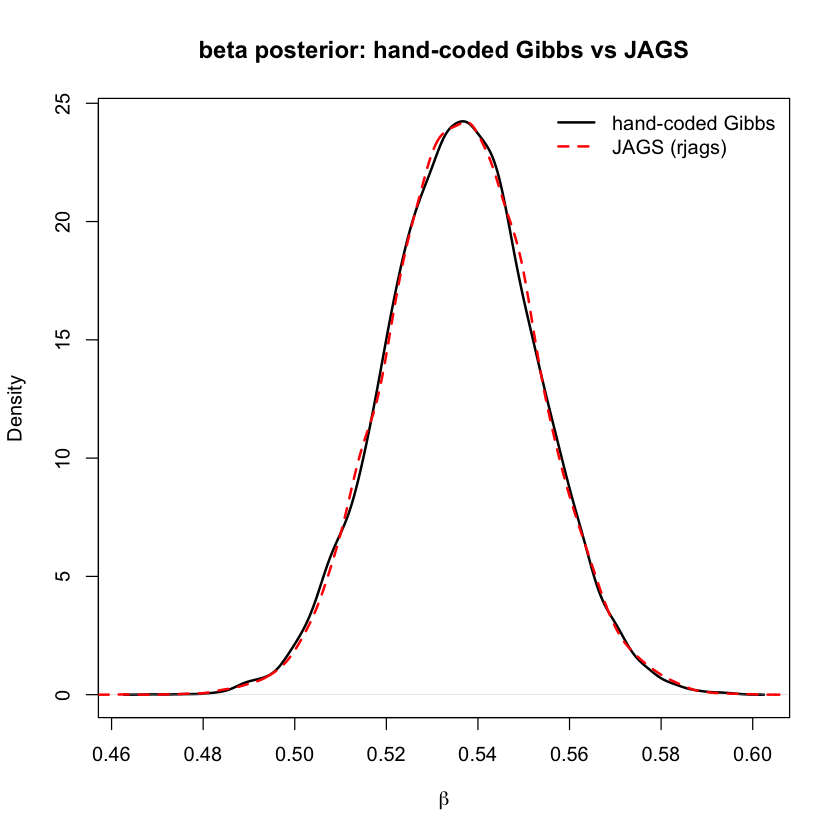

In [35]:
Bjags <- as.matrix(sj)[, "beta"]
cat(sprintf("Hand-coded Gibbs  beta = %.3f   95%% CrI [%.3f, %.3f]\n",
    mean(B), quantile(B,.025), quantile(B,.975)))
cat(sprintf("JAGS  (rjags)     beta = %.3f   95%% CrI [%.3f, %.3f]\n",
    mean(Bjags), quantile(Bjags,.025), quantile(Bjags,.975)))
cat(sprintf("P(beta > 3/4):  hand-coded = %.3f    JAGS = %.3f\n", mean(B>0.75), mean(Bjags>0.75)))
plot(density(B), lwd = 2, xlab = expression(beta), main = "beta posterior: hand-coded Gibbs vs JAGS")
lines(density(Bjags), col = "red", lwd = 2, lty = 2)
legend("topright", bty="n", c("hand-coded Gibbs","JAGS (rjags)"), col=c("black","red"), lwd=2, lty=c(1,2))

The two engines agree to within Monte-Carlo error — the posterior means and credible intervals coincide, the density curves overlie one another, and $P(\beta>3/4)=0$ in both. A from-scratch Gibbs sampler and JAGS reaching the identical posterior confirms the result is a property of the **data and the model**.

## 8. Discussion and conclusions

**Is Kleiber's law universal? No — at least not in this curated basal subset.**

* The free-exponent posterior is $\beta = 0.54\ (95\%\ \text{CrI}\ 0.50\text{–}0.57)$. Kleiber's $3/4$ and the surface-law $2/3$ both fall outside this interval, and $P(\beta>3/4\mid\text{data})=0$. The data favour a markedly shallower exponent.
* Model comparison is decisive: the DIC drops from **571** (fixed $3/4$) to **438** (free slope) to **366** (group-dependent), i.e. $\Delta\text{DIC}\approx132$ and then a further $73$. A single exponent is inadequate, and the rigid Kleiber model is by far the worst.
* The two classes differ in *both* slope and elevation: mammals scale more steeply ($\beta\approx0.63$) than birds ($\beta\approx0.53$, with $P(\beta_{\text{Mam}}>\beta_{\text{Aves}})\approx1$), while birds sit higher at a given mass ($\alpha_{\text{Aves}}=1.25$ vs $\alpha_{\text{Mam}}=1.01$). Pooling these two offset grades is what drags the single-line exponent down to $0.54$.
* For a 1 kg animal we predict $\approx 2.8$ W, with Kleiber's 3.4 W just outside the credible band for the mean but inside the individual predictive band.

**Why so shallow?** Two effects combine. First, the basal subset of AnimalTraits is taxonomically heterogeneous and unevenly distributed in mass — small, high-rate passerines crowd the low-mass end while larger mammals fill the high-mass end. Second, and more importantly, the two classes form roughly parallel *grades* offset in elevation (birds above mammals); fitting one line through two such grades that occupy different mass ranges tilts the pooled slope below either within-class slope. This is precisely why Model 3 is so strongly favoured, and why the within-class slopes ($0.53$ and $0.63$) sit above the pooled $0.54$.

**Caveats.** The observations are not phylogenetically independent (a fuller analysis would add a phylogenetic random effect), a few species appear more than once, and the basal subset is a non-random slice of all endotherms. These are natural extensions. Within the project's scope, the conclusion is robust: the exponent is reliably below $3/4$, and a group-structured model is needed to describe metabolic scaling across mammals and birds.

**References.**
* M. Kleiber, *The Fire of Life: An Introduction to Animal Energetics*, Wiley (1961).
* M. E. Herberstein *et al.*, "AnimalTraits – a curated animal trait database for body mass, metabolic rate and brain size," *Scientific Data* **9**, 265 (2022).